In [3]:
# This mounts your Google Drive to the Colab VM.
from google.colab import drive
drive.mount('/content/drive')

# TODO: Enter the foldername in your Drive where you have saved the unzipped
# e.g. Colab Notebooks/Aprendizado Profundo para Reconhecimento Visual/02_image-classification'
FOLDERNAME = 'Colab Notebooks/Aprendizado Profundo para Reconhecimento Visual/02_image-classification'
assert FOLDERNAME is not None, '[!] Enter the foldername.'

Mounted at /content/drive


In [6]:
%cd /content/drive/MyDrive/$FOLDERNAME
!gdown --id 1NUGtNIABwt4PSAkBXPcMtnKPPaZYmxP3 -O utils.py

/content/drive/MyDrive/Colab Notebooks/Aprendizado Profundo para Reconhecimento Visual/02_image-classification
/usr/local/lib/python3.13/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1NUGtNIABwt4PSAkBXPcMtnKPPaZYmxP3
From (redirected): https://drive.google.com/uc?id=1NUGtNIABwt4PSAkBXPcMtnKPPaZYmxP3&confirm=t&uuid=a468766d-5ea0-45a3-9498-c5253cc01232
To: /content/drive/MyDrive/Colab Notebooks/Aprendizado Profundo para Reconhecimento Visual/02_image-classification/utils.py
100% 4.49k/4.49k [00:00<00:00, 18.4MB/s]


In [10]:
import os
from sklearn.datasets import fetch_openml
import numpy as np

# Create dataset directory if it not existing
os.makedirs('dataset', exist_ok=True)

# Define the directory and file paths for saving the dataset
cache_dir = 'dataset/mnist'
os.makedirs(cache_dir, exist_ok=True)

# Path to data
X_file_path = f"{cache_dir}/X.npy"
y_file_path = f"{cache_dir}/y.npy"

# Check if the dataset files already exist
if not (os.path.exists(X_file_path) and os.path.exists(y_file_path)):
    # Download the MNIST dataset
    mnist = fetch_openml('mnist_784', as_frame=False, cache=True, return_X_y=True)

    # Extract features and labels
    X, y = mnist
    print(X)
    # Save the dataset as numpy arrays
    np.save(X_file_path, X.astype(np.float32))
    np.save(y_file_path, y)
    print(f"MNIST dataset downloaded and saved successfully to {cache_dir}.")
else:
    X = np.load(X_file_path)
    y = np.load(y_file_path)
    print(f"MNIST dataset already exists in {cache_dir}. Skipping download.")

print(X.shape)
print(X.min(), X.max())

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
MNIST dataset downloaded and saved successfully to dataset/mnist.
(70000, 784)
0 255


[    1    21    34 ... 69964 69983 69993]
[    3     6     8 ... 69978 69984 69994]
[    5    16    25 ... 69980 69985 69995]
[    7    10    12 ... 69975 69986 69996]
[    2     9    20 ... 69977 69987 69997]
[    0    11    35 ... 69982 69988 69998]
[   13    18    32 ... 69981 69989 69999]
[   15    29    38 ... 69968 69979 69990]
[   17    31    41 ... 69959 69967 69991]
[    4    19    22 ... 69945 69973 69992]


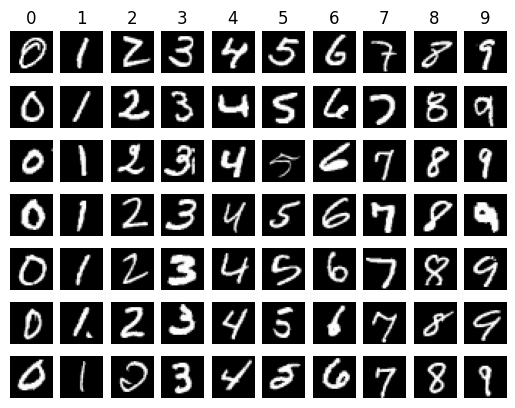

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Visualize some examples from the dataset.
# We show a few examples of training images from each class.
classes = [i for i in range(10)]
num_classes = len(classes)
samples_per_class = 7
for cls in classes:
    idxs = np.flatnonzero(y == str(cls))
    print(idxs)
    idxs = np.random.choice(idxs, samples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + cls + 1
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(X[idx].reshape((28, -1)).astype('uint8'), cmap="gray")
        plt.axis('off')
        if i == 0:
            plt.title(cls)
plt.show()